In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score,classification_report

In [2]:
df=sns.load_dataset("diamonds")

In [3]:
encoder=LabelEncoder()
df["cut"]=encoder.fit_transform(df["cut"])
df["color"]=encoder.fit_transform(df["color"])
df["clarity"]=encoder.fit_transform(df["clarity"])

In [4]:
X=df

In [5]:
scaler=StandardScaler()

In [6]:
X_scaled=scaler.fit_transform(X)

In [7]:
model=IsolationForest(n_estimators=100,contamination=0.03,random_state=42)
model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [8]:
pre=model.predict(X_scaled)

In [9]:
df["Anomaly"] = pre

In [10]:
normal = df[df["Anomaly"] == 1]
anomaly = df[df["Anomaly"] == -1]


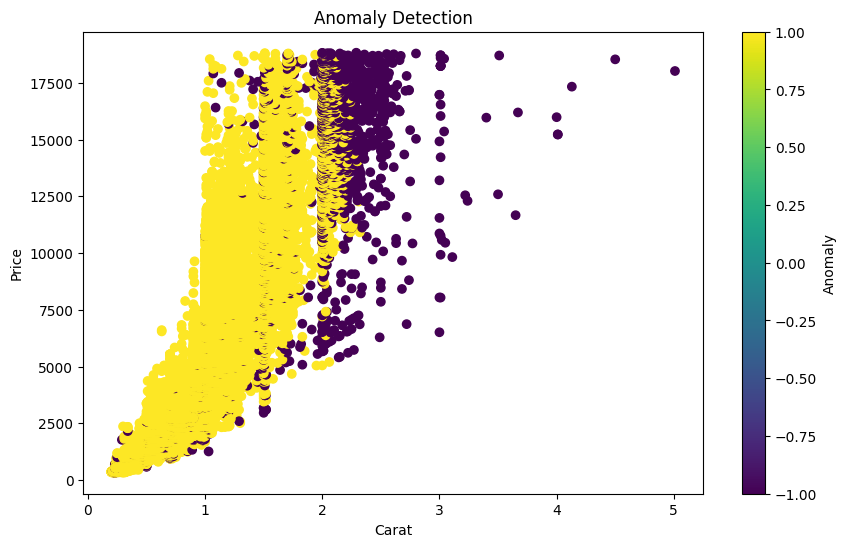

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["carat"],
    df["price"],
    c=df["Anomaly"],
)

plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Anomaly Detection")

plt.colorbar(label="Anomaly")

plt.show()